<a href="https://colab.research.google.com/github/HumphreyChimanya/Bank_Transactions_Fraud_Detection_Notebook/blob/main/BankTransactionsFraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip archive.zip -d fraud-data

Archive:  archive.zip
  inflating: fraud-data/Bank_Transaction_Fraud_Detection.csv  


In [3]:
import pandas as pd

df = pd.read_csv('/content/fraud-data/Bank_Transaction_Fraud_Detection.csv')
display(df.head())

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [4]:
# Check data types and general info
print("=== DataFrame Info ===")
df.info()

# Check for missing values in each column
print("\n=== Missing Values Count ===")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-

'No missing values found!'

In [5]:
# Calculate and display summary statistics for numerical columns
numerical_summary = df.describe()
display(numerical_summary)

,Age,Transaction_Amount,Account_Balance,Is_Fraud
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,49538.015554,52437.988784,0.050440
std,15.288774,28551.874004,27399.507128,0.218852
min,18.000000,10.290000,5000.820000,0.000000
25%,31.000000,24851.345000,28742.395000,0.000000
50%,44.000000,49502.440000,52372.555000,0.000000
75%,57.000000,74314.625000,76147.670000,0.000000
max,70.000000,98999.980000,99999.950000,1.000000


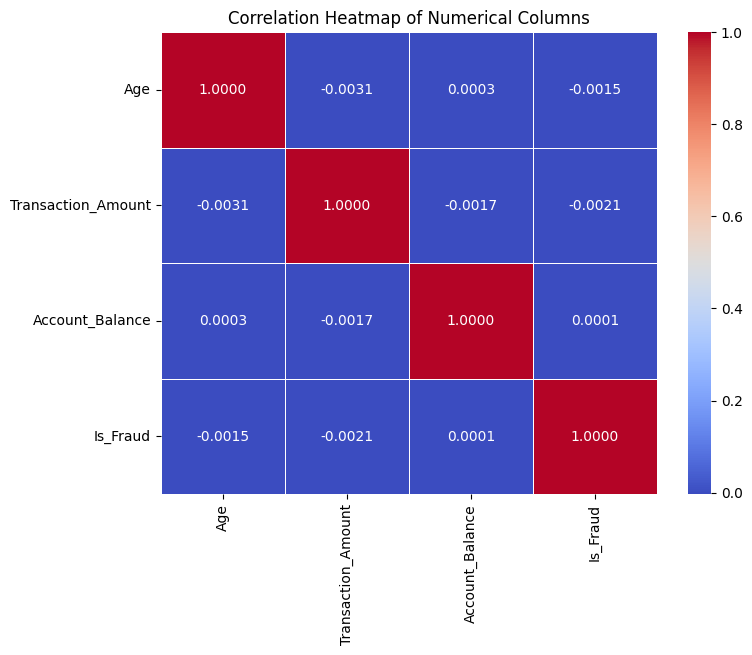

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter numerical columns
numerical_cols = ['Age', 'Transaction_Amount', 'Account_Balance', 'Is_Fraud']
corr_matrix = df[numerical_cols].corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.4f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

In [7]:
# Filter for fraudulent transactions
fraud_df = df[df['Is_Fraud'] == 1]

# Group by Merchant_ID and count fraud occurrences
top_fraud_merchants = fraud_df.groupby('Merchant_ID').size().reset_index(name='Fraud_Count')

# Sort in descending order and get top 5
top_5_merchants = top_fraud_merchants.sort_values(by='Fraud_Count', ascending=False).head(5)

print("Top 5 Merchants with the Highest Number of Fraud Cases:")
display(top_5_merchants)

Top 5 Merchants with the Highest Number of Fraud Cases:


,Merchant_ID,Fraud_Count
10087,fffc5ab9-acbd-4937-8b65-688986ceaac5,1
0,000875cf-c11f-4e9e-9fee-f95d1a091bf0,1
1,000f554a-a45e-464a-91c1-e12fb294184c,1
2,0022e7f7-6a0e-4720-a4a6-2067c1df2b6c,1
3,0025144a-4305-42df-8db5-d9069f144ed3,1


### Feature Engineering
We will extract temporal properties, compute user transaction frequencies, and set up our features for modeling.

In [8]:
import pandas as pd
import numpy as np

# Create a copy to keep the original DataFrame intact
fe_df = df.copy()

# 1. Parse Date and Time Features
# Convert Date to datetime format
fe_df['Transaction_Date'] = pd.to_datetime(fe_df['Transaction_Date'])

# Extract temporal attributes
fe_df['Transaction_Year'] = fe_df['Transaction_Date'].dt.year
fe_df['Transaction_Month'] = fe_df['Transaction_Date'].dt.month
fe_df['Transaction_Day'] = fe_df['Transaction_Date'].dt.day
fe_df['Transaction_DayOfWeek'] = fe_df['Transaction_Date'].dt.dayofweek
fe_df['Is_Weekend'] = fe_df['Transaction_DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Extract Hour from Transaction_Time (Format is assumed HH:MM:SS)
fe_df['Transaction_Hour'] = pd.to_datetime(fe_df['Transaction_Time'], format='%H:%M:%S', errors='coerce').dt.hour
# If format varied, fallback to string splitting:
if fe_df['Transaction_Hour'].isnull().any():
    fe_df['Transaction_Hour'] = fe_df['Transaction_Time'].apply(lambda x: int(str(x).split(':')[0]) if pd.notnull(x) else np.nan)

# 2. Customer and Transaction Behavioral Features
# Calculate customer-level transaction frequency
customer_tx_counts = fe_df.groupby('Customer_ID').size().reset_index(name='Customer_Tx_Count')
fe_df = fe_df.merge(customer_tx_counts, on='Customer_ID', how='left')

# Calculate customer-level average transaction amount
customer_avg_amount = fe_df.groupby('Customer_ID')['Transaction_Amount'].mean().reset_index(name='Customer_Avg_Tx_Amount')
fe_df = fe_df.merge(customer_avg_amount, on='Customer_ID', how='left')

# Ratio of current transaction amount to customer's average transaction amount
fe_df['Tx_Amount_To_Avg_Ratio'] = fe_df['Transaction_Amount'] / (fe_df['Customer_Avg_Tx_Amount'] + 1e-5)

# Display sample of engineered features
display(fe_df[['Customer_ID', 'Transaction_Date', 'Transaction_Hour', 'Is_Weekend', 'Customer_Tx_Count', 'Tx_Amount_To_Avg_Ratio', 'Is_Fraud']].head())


/tmp/ipykernel_1423/3463695641.py:9: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  fe_df['Transaction_Date'] = pd.to_datetime(fe_df['Transaction_Date'])


,Customer_ID,Transaction_Date,Transaction_Hour,Is_Weekend,Customer_Tx_Count,Tx_Amount_To_Avg_Ratio,Is_Fraud
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,2025-01-23,16,0,1,1.0,0
1,7c14ad51-781a-4db9-b7bd-67439c175262,2025-01-11,17,1,1,1.0,0
2,3a73a0e5-d4da-45aa-85f3-528413900a35,2025-01-25,3,1,1,1.0,0
3,7902f4ef-9050-4a79-857d-9c2ea3181940,2025-01-19,12,1,1,1.0,0
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,2025-01-30,18,0,1,1.0,0


### Categorical Encoding & Dataset Splitting
Now we will select our target feature, encode categorical variables using One-Hot Encoding, and prepare our final dataset `X` and target `y`.

In [9]:
# Select features for modeling
feature_cols = [
    'Age', 'Transaction_Amount', 'Account_Balance',
    'Transaction_Hour', 'Is_Weekend', 'Customer_Tx_Count', 'Tx_Amount_To_Avg_Ratio',
    'Gender', 'Account_Type', 'Transaction_Type', 'Device_Type'
]

# Filter features and target
X = fe_df[feature_cols].copy()
y = fe_df['Is_Fraud'].copy()

# Convert categorical columns using One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=['Gender', 'Account_Type', 'Transaction_Type', 'Device_Type'], drop_first=True)

print("Final feature matrix shape:", X_encoded.shape)
print("Features preview:")
display(X_encoded.head())


Final feature matrix shape: (200000, 17)
Features preview:


,Age,Transaction_Amount,Account_Balance,Transaction_Hour,Is_Weekend,Customer_Tx_Count,Tx_Amount_To_Avg_Ratio,Gender_Male,Account_Type_Checking,Account_Type_Savings,Transaction_Type_Credit,Transaction_Type_Debit,Transaction_Type_Transfer,Transaction_Type_Withdrawal,Device_Type_Desktop,Device_Type_Mobile,Device_Type_POS
0,60,32415.45,74557.27,16,0,1,1.0,True,False,True,False,False,True,False,False,False,True
1,51,43622.60,74622.66,17,1,1,1.0,False,False,False,False,False,False,False,True,False,False
2,20,63062.56,66817.99,3,1,1,1.0,True,False,True,False,False,False,False,True,False,False
3,57,14000.72,58177.08,12,1,1,1.0,False,False,False,False,True,False,False,False,True,False
4,43,18335.16,16108.56,18,0,1,1.0,False,False,True,False,False,True,False,False,True,False


### Model Training and Evaluation
We will split our preprocessed dataset into stratified training and test sets, train three different classification models, evaluate their metrics, and compare their performance.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support
import pandas as pd

# 1. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scale Numerical Features
scaler = StandardScaler()
# Fit scaler on train set and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models to train
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

results = []

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Convert results to DataFrame for comparison
comparison_df = pd.DataFrame(results)
display(comparison_df)

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.051794,0.492071,0.093723,0.508191
1,Random Forest,0.056727,0.150644,0.082418,0.508592
2,Gradient Boosting,0.000000,0.000000,0.000000,0.510275


### Advanced Techniques: SMOTE and XGBoost
We will install `imblearn` if needed, apply SMOTE to balance the training set, and then train and evaluate an XGBoost Classifier.

In [11]:
# Install imbalanced-learn for SMOTE and xgboost if not already present
!pip install -q imbalanced-learn xgboost

In [12]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support
import pandas as pd

# 1. Apply SMOTE only to the training data to prevent data leakage
print("Original training class distribution:", np.bincount(y_train))
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print("Resampled training class distribution:", np.bincount(y_train_resampled))

# 2. Train XGBoost on the resampled data
print("\nTraining XGBoost on SMOTE-balanced data...")
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_resampled, y_train_resampled)

# 3. Predict and Evaluate
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

precision_xgb, recall_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average='binary')
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

# Add to our previous results
advanced_result = {
    "Model": "XGBoost (with SMOTE)",
    "Precision": precision_xgb,
    "Recall": recall_xgb,
    "F1-Score": f1_xgb,
    "ROC-AUC": roc_auc_xgb
}

all_results_df = pd.concat([comparison_df, pd.DataFrame([advanced_result])], ignore_index=True)
display(all_results_df)

Original training class distribution: [151930   8070]
Resampled training class distribution: [151930 151930]

Training XGBoost on SMOTE-balanced data...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [16:20:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.051794,0.492071,0.093723,0.508191
1,Random Forest,0.056727,0.150644,0.082418,0.508592
2,Gradient Boosting,0.000000,0.000000,0.000000,0.510275
3,XGBoost (with SMOTE),0.000000,0.000000,0.000000,0.505737
